In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import shutil
import re
import seaborn as sns
from itertools import combinations
import numpy as np
#from pymatgen.core.structure import Structure

import pylab
pd.set_option('display.max_rows', None)
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import scipy
import unicodeit
%matplotlib inline

In [40]:
N2_ads_comparison = pd.read_csv('/Users/parastooagharezaei/Downloads/move_toPC/N2_bader_charge/N2_final_comparison.csv')
N2_median_comparison = pd.read_csv('/Users/parastooagharezaei/Downloads/move_toPC/N2_bader_charge/medians_N2.csv')

H2_ads_comparison = pd.read_csv('/Users/parastooagharezaei/Downloads/move_toPC/H2_analysis/H2_final_comparison.csv')
H2_median_comparison = pd.read_csv('/Users/parastooagharezaei/Downloads/move_toPC/H2_analysis/median_H2.csv')
HER_path = pd.read_csv('/Users/parastooagharezaei/Downloads/copied_all_mols_reactions_path/HER_path.csv')

ass_alternating_df = pd.read_csv('/Users/parastooagharezaei/Downloads/copied_all_mols_reactions_path/path1_s1.csv')
dissc_df = pd.read_csv('/Users/parastooagharezaei/Downloads/copied_all_mols_reactions_path/path3_s1.csv')


In [25]:
dissc_df

,2N*,2NH*,2NH2*,2NH3*,2NH3 + *,path,system
0,0.620702,-1.631198,-0.620655,-0.532375,1.116656,path_3,0_CuNi
1,-0.712411,-0.747622,0.411263,-1.091564,1.093465,path_3,1_Ag_subCu
2,-0.695529,-0.673113,-0.089192,-0.719246,1.130210,path_3,2_Au_subCu
3,0.646835,-1.039376,-0.529523,-1.247433,1.122627,path_3,6_Pd_subNi
4,0.396015,-0.853671,-0.921434,-0.895968,1.228188,path_3,7_Pt_subNi
5,0.646214,-1.197729,-0.846395,-0.847456,1.198496,path_3,9_Fe_subNi
6,0.592065,-1.093319,-0.788065,-0.963875,1.206324,path_3,11_Pd_subCu
7,-0.061192,-0.974573,-0.623284,-0.496913,1.109092,path_3,13_Ag_subNi
8,0.007416,-0.983607,-0.695147,-0.533345,1.157812,path_3,14_Au_subNi


In [26]:
N2_vert_stat = [i/19 for i in N2_ads_comparison['n_vertical_mol']]
N2_vert_ads = [i*(-1) for i in N2_median_comparison['ads_vert_NN_adsE']]

H2_stat = [1-(i/19) for i in H2_ads_comparison['n_adsorbed + n_dissociated']]
H2_ads = [i for i in HER_path['*H']]

N2_horz_stat = [i/19 for i in N2_ads_comparison['n_horiz_mol']]
N2_horz_ads = [i*(-1) for i in N2_median_comparison['ads_horiz_NN_adsE']]

N2H_barr = [-i for i in ass_alternating_df['*N2H']] #[1/i for i in ass_alternating_df['*N2H']]
NH3_barr = [-i for i in ass_alternating_df['2NH3 + *']]

#in AgCu barrier is not *N but NH2 with 0.41eV 
N_barr = [-i for i in dissc_df['2N*']]
N_barr[1] = 0.41



In [27]:
systems = ['CuNi','Ag@Cu', 'Au@Cu', 'Pd@Ni', 'Pt@Ni', 'Fe@Ni','Pd@Cu', 'Ag@Ni', 'Au@Ni']
rank_N2_vert_adsorption_stat = [5, 6, 3, 1, 2, 4, 5, 2, 3]
rank_N2_horz_adsorption_stat = [1, 4, 6, 8, 5, 3, 2, 5, 7]
rank_H2_adsorption_stat =      [1, 6, 3, 2, 5, 5, 6, 4, 7]
rank_H2_adsorption_energy =    [6, 8, 5, 2, 1, 3, 4, 7, 9]
rank_reaction_alt =            [9, 8, 2, 6, 5, 7, 3, 4, 1]
rank_reaction_distal =         [9, 8, 2, 6, 5, 7, 3, 4, 1]
rank_reaction_dissc =          [7, 1, 2, 7, 5, 7, 6, 3, 4]

df_comparison_final = pd.DataFrame()

df_comparison_final['system'] = systems
df_comparison_final['rank_N2_vert'] = rank_N2_vert_adsorption_stat
df_comparison_final['rank_N2_horz'] = rank_N2_horz_adsorption_stat
df_comparison_final['rank_H2_adsorption_stat'] = rank_H2_adsorption_stat
df_comparison_final['rank_H2_adsorption_energy'] = rank_H2_adsorption_energy
df_comparison_final['rank_reaction_barrier_alt'] = rank_reaction_alt
df_comparison_final['rank_reaction_barrier_distal'] = rank_reaction_distal
df_comparison_final['rank_reaction_barrier_dissc'] = rank_reaction_dissc

In [28]:
alt =['system','rank_N2_vert','rank_H2_adsorption_stat','rank_H2_adsorption_energy','rank_reaction_barrier_alt']
distal = ['system','rank_N2_vert','rank_H2_adsorption_stat','rank_H2_adsorption_energy','rank_reaction_barrier_distal']
dissc = ['system','rank_N2_horz','rank_H2_adsorption_stat','rank_reaction_barrier_dissc']

df_comp_alt = df_comparison_final[alt] 
df_comp_alt['final_rank'] = df_comp_alt.sum(axis=1, numeric_only=True)


df_comp_distal = df_comparison_final[distal]
df_comp_distal['final_rank'] = df_comp_distal.sum(axis=1, numeric_only=True)

df_comp_dissc = df_comparison_final[dissc]
df_comp_dissc['final_rank'] = df_comp_dissc.sum(axis=1, numeric_only=True)

/var/folders/r1/kkbjz55s5kvd_39rylxw77n40000gn/T/ipykernel_6793/1923252293.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comp_alt['final_rank'] = df_comp_alt.sum(axis=1, numeric_only=True)
/var/folders/r1/kkbjz55s5kvd_39rylxw77n40000gn/T/ipykernel_6793/1923252293.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comp_distal['final_rank'] = df_comp_distal.sum(axis=1, numeric_only=True)
/var/folders/r1/kkbjz55s5kvd_39rylxw77n40000gn/T/ipykernel_6793/1923252293.py:13: SettingWithCopyWarning: 
A 

In [29]:
df_assoc = pd.DataFrame({
'group': ['CuNi','Ag@Cu', 'Au@Cu', 'Pd@Ni', 'Pt@Ni', 'Fe@Ni','Pd@Cu', 'Ag@Ni', 'Au@Ni'],
'N2 Adsorption Rate': N2_vert_stat,
'N2 Bonding Energy': N2_vert_ads,
'H2/2H Adsorption Rate': H2_stat,
'H Bonding Energy': H2_ads ,
'*N2H Uphill Energy': N2H_barr,
'*NH3 Uphill Energy': NH3_barr
})

df_dissoc = pd.DataFrame({
'group': ['CuNi','Ag@Cu', 'Au@Cu', 'Pd@Ni', 'Pt@Ni', 'Fe@Ni','Pd@Cu', 'Ag@Ni', 'Au@Ni'],
'N2 Adsorption Rate': N2_horz_stat,
'N2 Bonding Energy': N2_horz_ads,
'H2/2H Adsorption Rate': H2_stat,
'H Bonding Energy': H2_ads ,
'*N Uphill Energy': N_barr,
'*NH3 Uphill Energy': NH3_barr
})

In [30]:
col_dict_assoc = {'group': 'group',
'N2 Adsorption Rate': 'var1',
'N2 Bonding Energy': 'var2',
'H2/2H Adsorption Rate': 'var3',
'H Bonding Energy': 'var4' ,
'*N2H Uphill Energy': 'var5',
'*NH3 Uphill Energy': 'var6'}

col_dict_dissoc = {
'group': 'group',
'N2 Adsorption Rate': 'var1',
'N2 Bonding Energy': 'var2',
'H2/2H Adsorption Rate': 'var3',
'H Bonding Energy': 'var4' ,
'*N Uphill Energy': 'var5',
'*NH3 Uphill Energy': 'var6'
}


In [31]:
H2_ads_comparison

,system,n_adsorbed + n_dissociated,n_adsorbed,n_dissociated,n_not_adsorbed,n_vertical_mol,n_horiz_mol
0,CuNi,16,3,13,3,0,3
1,Ag@Cu,18,3,15,1,0,3
2,Au@Cu,18,5,13,1,0,5
3,Pd@Ni,17,4,13,2,0,4
4,Pt@Ni,17,3,14,2,0,3
5,Fe@Ni,17,3,14,2,0,3
6,Pd@Cu,18,3,15,1,0,3
7,Ag@Ni,16,2,14,3,0,2
8,Au@Ni,17,1,16,2,0,1


In [32]:
df_assoc

,group,N2 Adsorption Rate,N2 Bonding Energy,H2/2H Adsorption Rate,H Bonding Energy,*N2H Uphill Energy,*NH3 Uphill Energy
0,CuNi,0.263158,0.7819,0.157895,-0.642175,-1.293179,-1.116656
1,Ag@Cu,0.263158,0.8152,0.052632,-0.734008,-1.292785,-1.093465
2,Au@Cu,0.526316,0.7653,0.052632,-0.609587,-0.966621,-1.130210
3,Pd@Ni,0.684211,0.7620,0.105263,-0.474520,-1.137665,-1.122627
4,Pt@Ni,0.578947,0.8447,0.105263,-0.454242,-1.103162,-1.228188
5,Fe@Ni,0.473684,0.7411,0.105263,-0.483422,-1.165940,-1.198496
6,Pd@Cu,0.263158,0.7970,0.052632,-0.507111,-1.015582,-1.206324
7,Ag@Ni,0.578947,0.8823,0.157895,-0.644583,-1.032544,-1.109092
8,Au@Ni,0.526316,0.8448,0.105263,-0.734733,-0.305977,-1.157812


In [33]:
#Normalized
df = df_assoc[df_assoc.columns[1:]]
df_assoc_normalized = (df-df.min())/(df.max()-df.min())
df_assoc_normalized['group'] = systems
df_assoc_cols = list(df_assoc_normalized.columns[:-1])
df_assoc_normalized = df_assoc_normalized[['group'] + df_assoc_cols]

df = df_dissoc[df_dissoc.columns[1:]]
df_dissoc_normalized = (df-df.min())/(df.max()-df.min())
df_dissoc_normalized['group'] = systems
df_dissoc_cols = list(df_dissoc_normalized.columns[:-1])
df_dissoc_normalized = df_dissoc_normalized[['group'] + df_dissoc_cols]


In [34]:
#Mean_normalized
df = df_assoc[df_assoc.columns[1:]]
m_df_assoc_normalized = (df-df.mean())/df.std()
m_df_assoc_normalized['group'] = systems
m_df_assoc_cols = list(m_df_assoc_normalized.columns[:-1])
m_df_assoc_normalized = m_df_assoc_normalized[['group'] + df_assoc_cols]

df = df_dissoc[df_dissoc.columns[1:]]
m_df_dissoc_normalized = (df-df.mean())/df.std()
m_df_dissoc_normalized['group'] = systems
m_df_dissoc_cols = list(m_df_dissoc_normalized.columns[:-1])
m_df_dissoc_normalized = m_df_dissoc_normalized[['group'] + df_dissoc_cols]


m_df_dissoc_normalized

,group,N2 Adsorption Rate,N2 Bonding Energy,H2/2H Adsorption Rate,H Bonding Energy,*N Uphill Energy,*NH3 Uphill Energy
0,CuNi,2.003469,0.282066,1.421338,-0.497900,-0.844331,0.717278
1,Ag@Cu,-0.117851,0.123994,-1.137070,-1.328921,1.193315,1.195650
2,Au@Cu,-1.885618,-2.647863,-1.137070,-0.203009,1.757790,0.437709
3,Pd@Ni,-0.471405,0.343966,0.142134,1.019244,-0.895995,0.594123
4,Pt@Ni,0.235702,0.441537,0.142134,1.202750,-0.400136,-1.583287
5,Fe@Ni,-0.117851,0.503787,0.142134,0.938693,-0.894768,-0.970826
6,Pd@Cu,0.235702,0.194987,-1.137070,0.724323,-0.787718,-1.132292
7,Ag@Ni,0.235702,0.348163,1.421338,-0.519697,0.503738,0.873295
8,Au@Ni,-0.117851,0.409363,0.142134,-1.335483,0.368105,-0.131650


In [35]:
df_dissoc

,group,N2 Adsorption Rate,N2 Bonding Energy,H2/2H Adsorption Rate,H Bonding Energy,*N Uphill Energy,*NH3 Uphill Energy
0,CuNi,0.578947,0.41890,0.157895,-0.642175,-0.620702,-1.116656
1,Ag@Cu,0.263158,0.39630,0.052632,-0.734008,0.410000,-1.093465
2,Au@Cu,0.000000,-0.00000,0.052632,-0.609587,0.695529,-1.130210
3,Pd@Ni,0.210526,0.42775,0.105263,-0.474520,-0.646835,-1.122627
4,Pt@Ni,0.315789,0.44170,0.105263,-0.454242,-0.396015,-1.228188
5,Fe@Ni,0.263158,0.45060,0.105263,-0.483422,-0.646214,-1.198496
6,Pd@Cu,0.315789,0.40645,0.052632,-0.507111,-0.592065,-1.206324
7,Ag@Ni,0.315789,0.42835,0.157895,-0.644583,0.061192,-1.109092
8,Au@Ni,0.263158,0.43710,0.105263,-0.734733,-0.007416,-1.157812


In [36]:
df_assoc_normalized

,group,N2 Adsorption Rate,N2 Bonding Energy,H2/2H Adsorption Rate,H Bonding Energy,*N2H Uphill Energy,*NH3 Uphill Energy
0,CuNi,0.000,0.288952,1.0,0.329986,0.000000,0.827858
1,Ag@Cu,0.000,0.524788,0.0,0.002585,0.000399,1.000000
2,Au@Cu,0.625,0.171388,0.0,0.446166,0.330791,0.727255
3,Pd@Ni,1.000,0.148017,0.5,0.927703,0.157530,0.783541
4,Pt@Ni,0.750,0.733711,0.5,1.000000,0.192480,0.000000
5,Fe@Ni,0.500,0.000000,0.5,0.895968,0.128888,0.220394
6,Pd@Cu,0.000,0.395892,0.0,0.811512,0.281196,0.162291
7,Ag@Ni,0.750,1.000000,1.0,0.321399,0.264014,0.884001
8,Au@Ni,0.625,0.734419,0.5,0.000000,1.000000,0.522371


In [37]:
df_comp_distal.sort_values(by='final_rank',ascending=True)

,system,rank_N2_vert,rank_H2_adsorption_stat,rank_H2_adsorption_energy,rank_reaction_barrier_distal,final_rank
3,Pd@Ni,1,2,2,6,11
2,Au@Cu,3,3,5,2,13
4,Pt@Ni,2,5,1,5,13
7,Ag@Ni,2,4,7,4,17
6,Pd@Cu,5,6,4,3,18
5,Fe@Ni,4,5,3,7,19
8,Au@Ni,3,7,9,1,20
0,CuNi,5,1,6,9,21
1,Ag@Cu,6,6,8,8,28


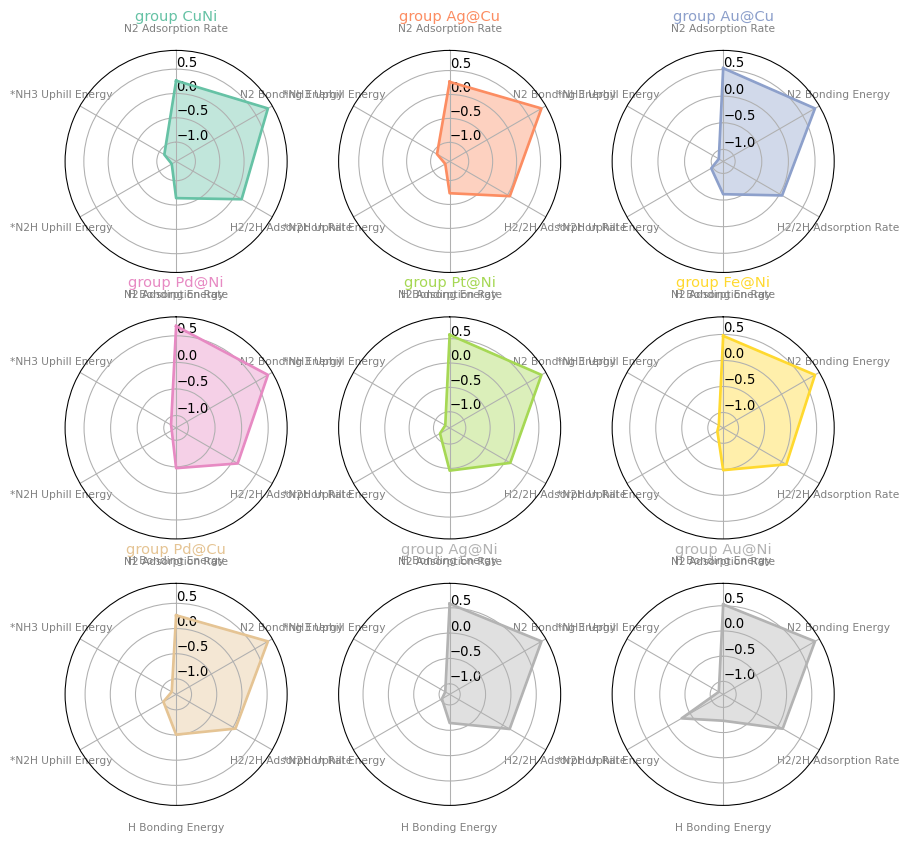

In [38]:
# Libraries
import matplotlib.pyplot as plt
import pandas as pd
from math import pi
pylab.rcParams['xtick.major.pad']='6' 
# Set data
df = df_assoc

#max_value = max(df_assoc_normalized.max(numeric_only=True).max(),df_dissoc_normalized.max(numeric_only=True).max())
#min_value = min(df_assoc_normalized.min(numeric_only=True).min(),df_dissoc_normalized.min(numeric_only=True).min())

 
# ------- PART 1: Define a function that do a plot for one line of the dataset!
 
def make_spider( row, title, color):

    # number of variable
    categories=list(df)[1:]
    N = len(categories)

    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialise the spider plot
    ax = plt.subplot(3,3,row+1, polar=True, )

    # If you want the first axis to be on top:
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], categories, color='grey', size=8)

    # Draw ylabels
    ax.set_rlabel_position(0)
    #plt.yticks([10,20,30], ["10","20","30"], color="grey", size=7)
    #max_value = float(df.max(numeric_only=True).max())
    #min_value = float(df.min(numeric_only=True).min())
    #plt.ylim(min_value,max_value)

    # Ind1
    values=df.loc[row].drop('group').values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)

    # Add a title
    plt.title(title, size=11, color=color, y=1.1)

    
# ------- PART 2: Apply the function to all individuals
# initialize the figure
my_dpi=96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)
 
# Create a color palette:
my_palette = plt.cm.get_cmap("Set2", len(df.index))
 
# Loop to plot
for row in range(0, len(df.index)):
    make_spider( row=row, title='group '+df['group'][row], color=my_palette(row))

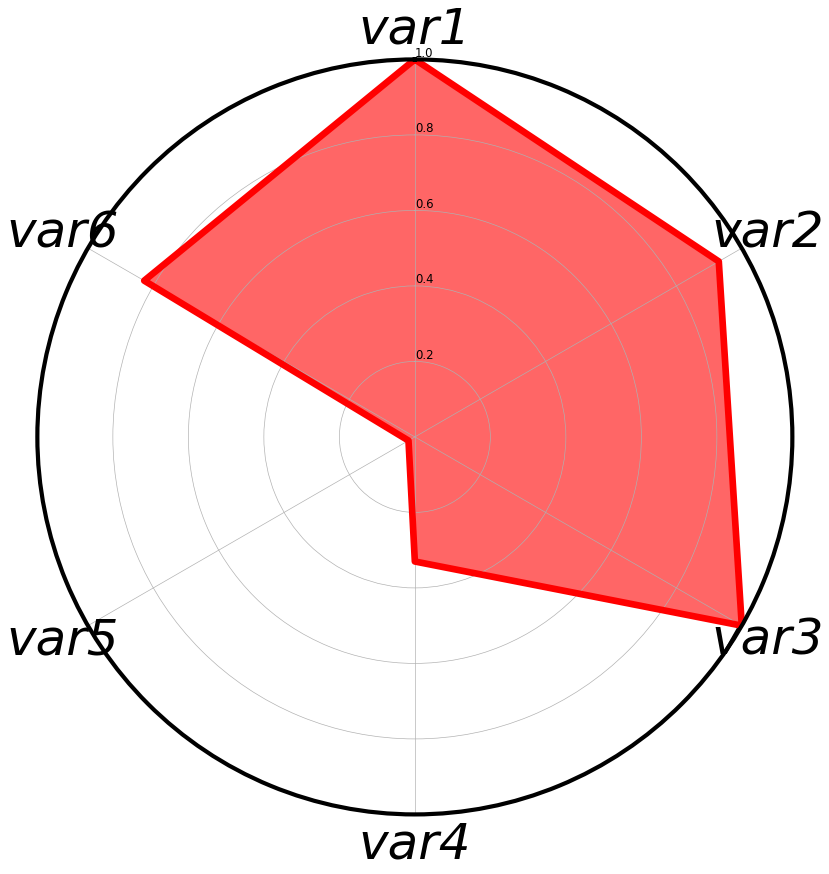

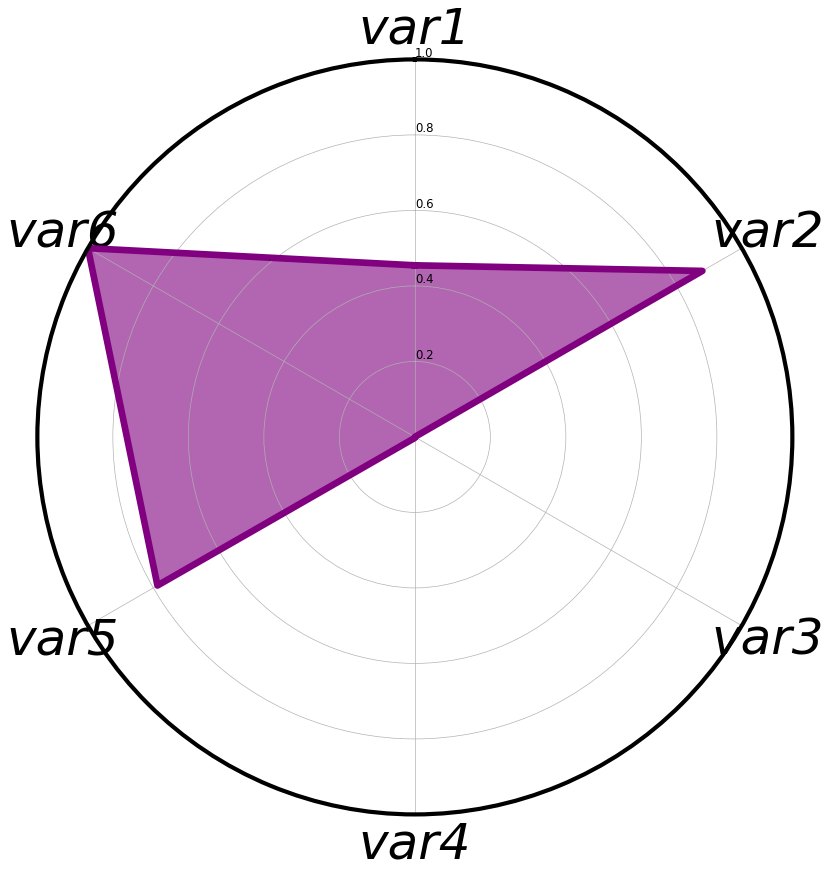

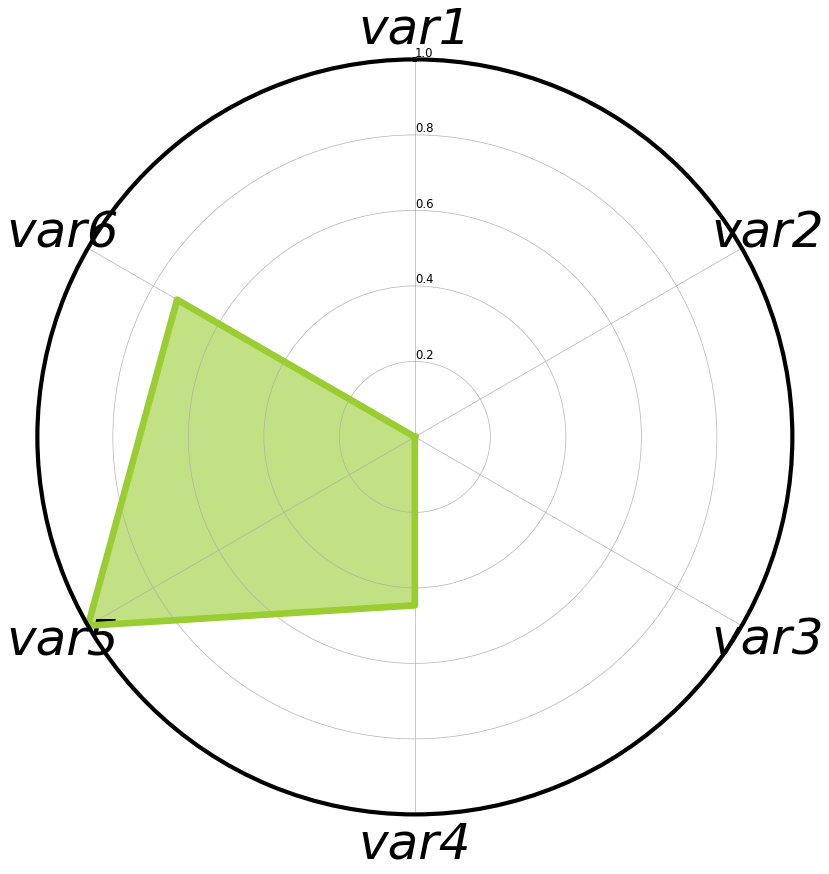

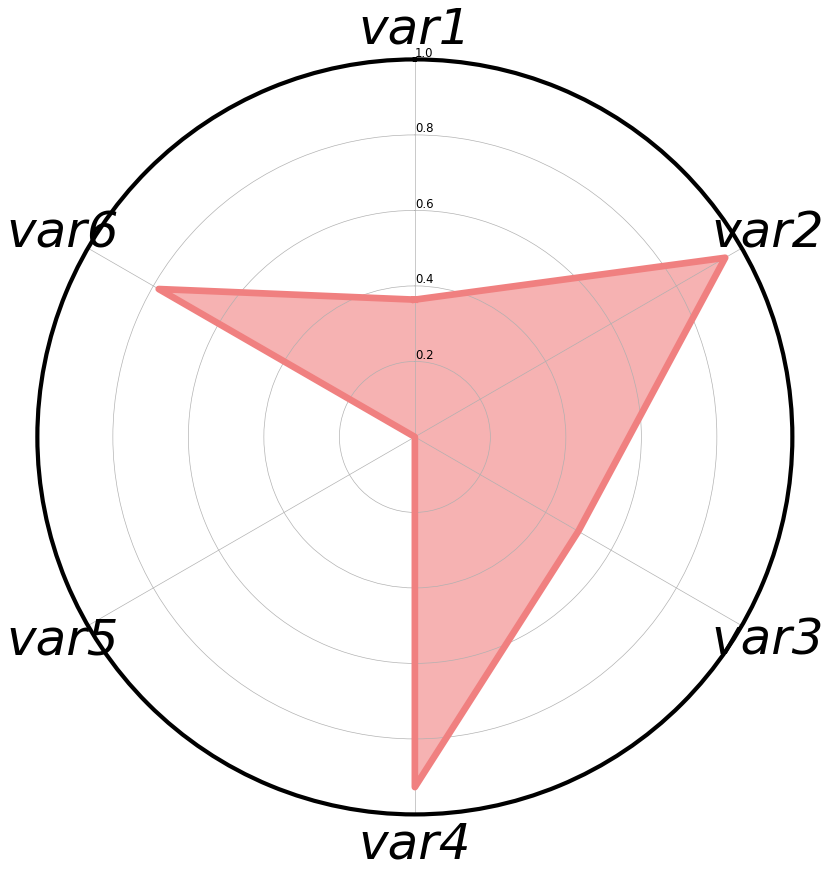

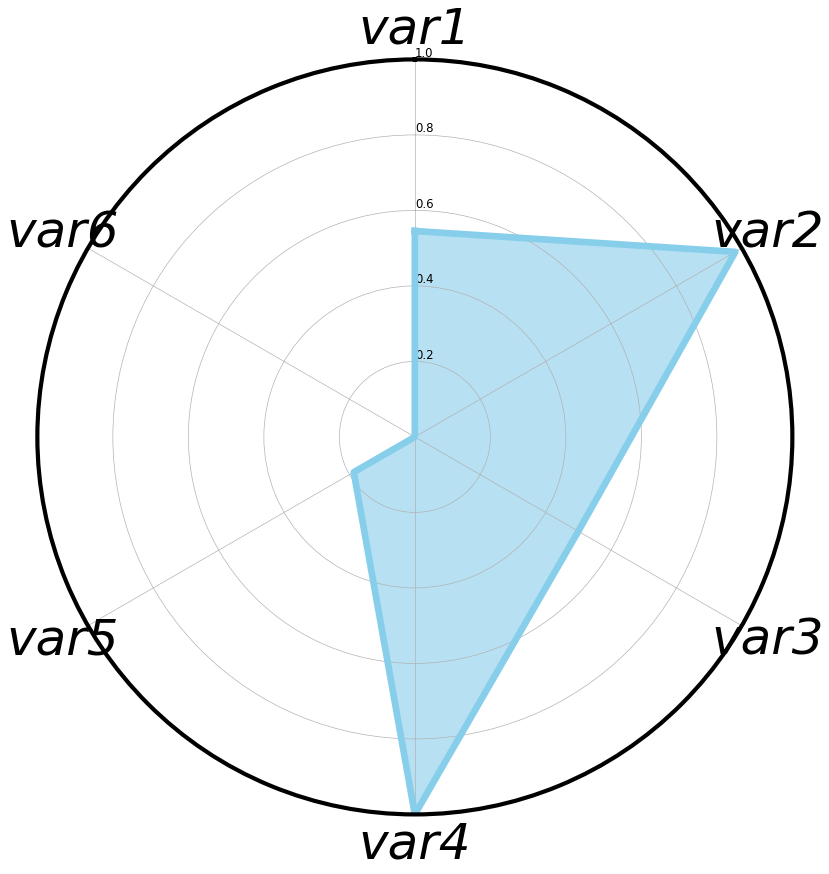

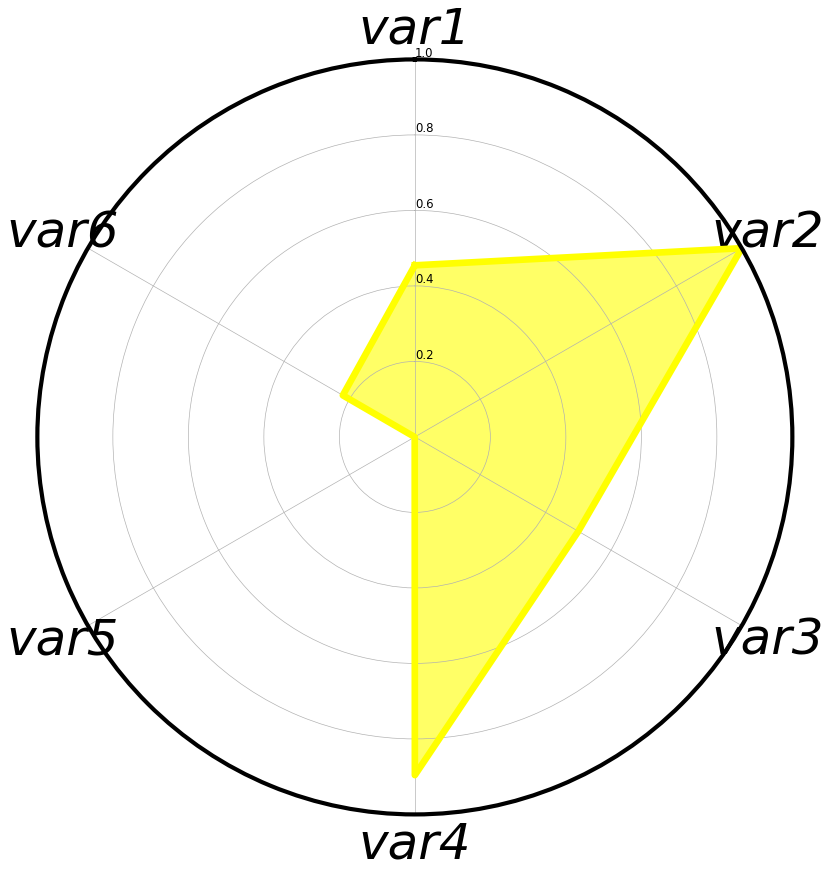

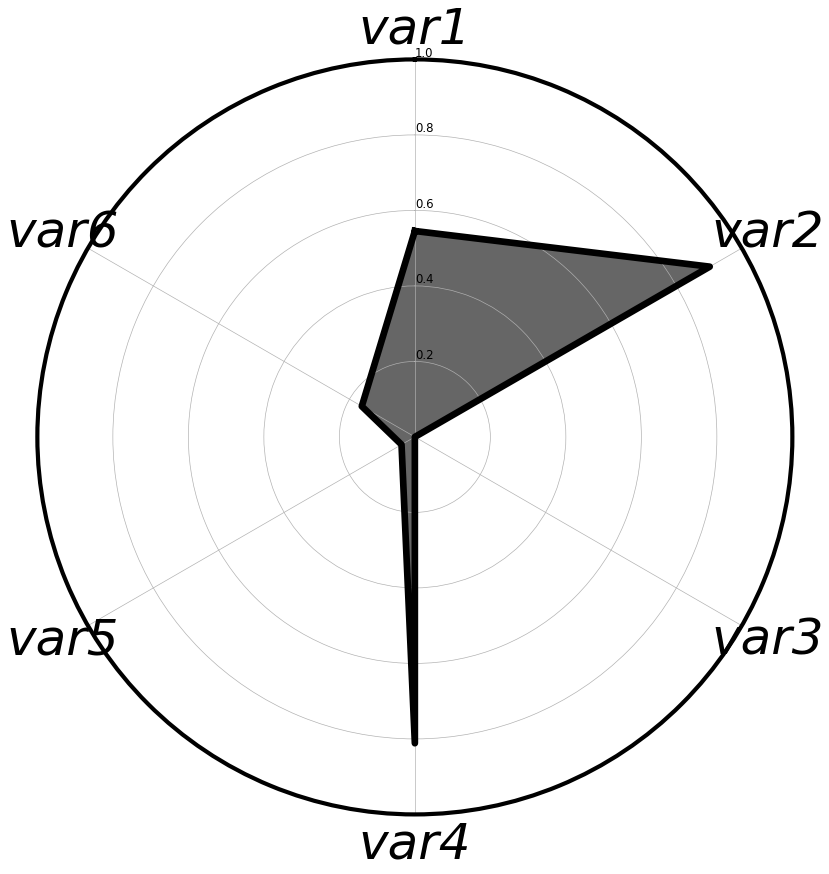

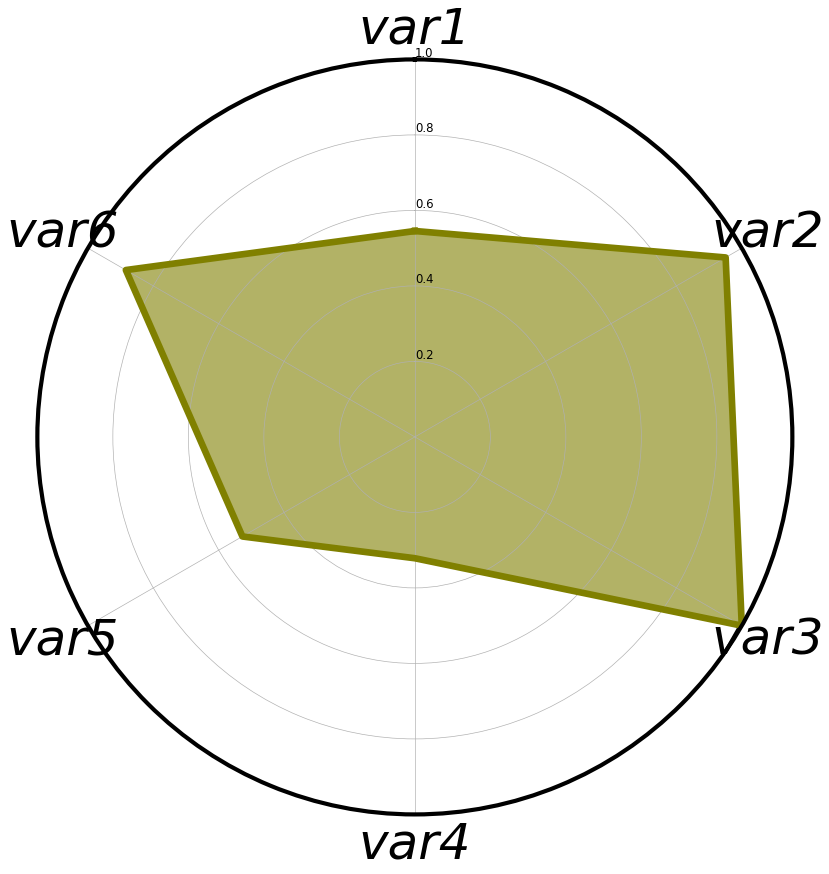

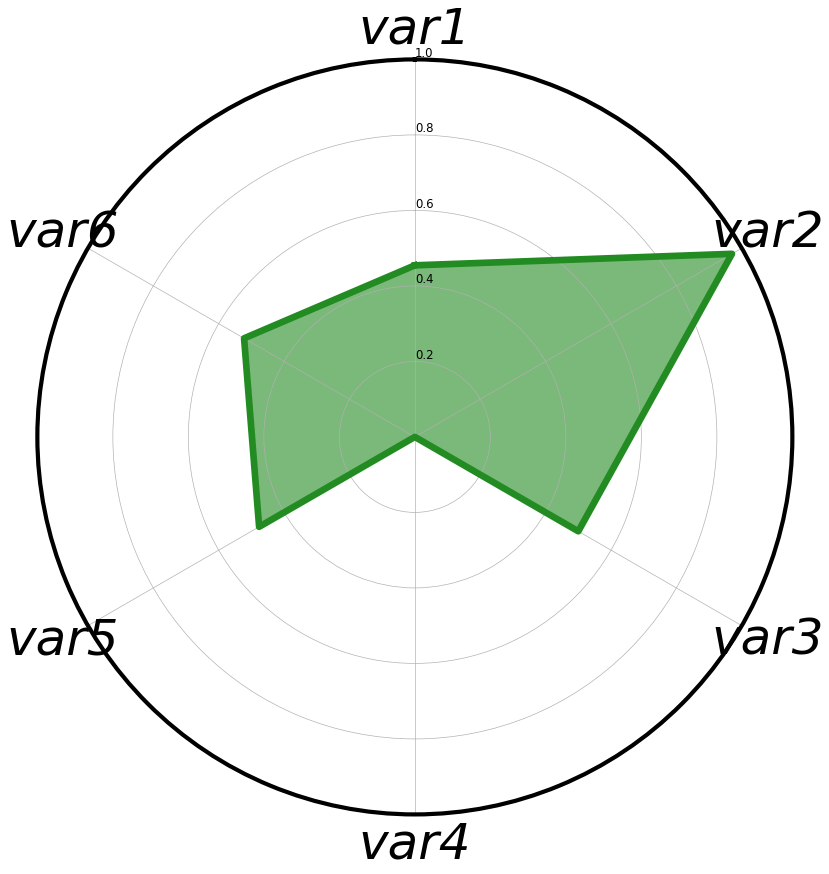

In [42]:
# Libraries
import matplotlib.pyplot as plt
import pandas as pd
from math import pi
pylab.rcParams['xtick.major.pad']='25' 

colors_dict =   {'CuNi': 'red',
                 'Pd@Ni': 'lightcoral',
                 'Pd@Cu': 'black',
                 'Fe@Ni': 'yellow',
                 'Ag@Cu': 'purple',
                 'Ag@Ni': 'olive',
                 'Pt@Ni': 'skyblue',
                 'Au@Cu': 'yellowgreen',
                 'Au@Ni': 'forestgreen',
                 'Pt@Cu': 'red',
                 'Fe@Cu': 'indianred',
                 'Co@Ni': 'green',
                 'Co@Cu': 'sandybrown',
                 'Ru@Ni': 'blue',
                 'Ru@Cu': 'orange'}
systems = ['CuNi','Ag@Cu', 'Au@Cu', 'Pd@Ni', 'Pt@Ni', 'Fe@Ni','Pd@Cu', 'Ag@Ni', 'Au@Ni']
colors_ = [colors_dict[i] for i in systems]

# Set data
pathway_type = 'dissoc'

if pathway_type == 'dissoc':
    col_dict = col_dict_dissoc 
    my_df = df_dissoc_normalized
elif pathway_type == 'assoc':
    col_dict = col_dict_assoc
    my_df = df_assoc_normalized

#my_df = m_df_dissoc_normalized
#max_value = float(my_df.max(numeric_only=True).max())
#min_value = float(my_df.min(numeric_only=True).min())

max_value = max(df_assoc_normalized.max(numeric_only=True).max(),df_dissoc_normalized.max(numeric_only=True).max())
min_value = min(df_assoc_normalized.min(numeric_only=True).min(),df_dissoc_normalized.min(numeric_only=True).min())

for i in range(len(my_df)):
    df = my_df.iloc[i:i+1].reset_index().drop(columns='index',axis=1)

    # ------- PART 1: Define a function that do a plot for one line of the dataset!

    def make_spider( row, title, color):

        # number of variable
        categories= [col_dict[i] for i in list(df)[1:]]
        N = len(categories)
        
        # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += angles[:1]

        # Initialise the spider plot
        ax = plt.subplot(1,1,row+1, polar=True, )
        plt.setp(ax.spines.values(), linewidth=5) #making the frame thicker
        
        
        # If you want the first axis to be on top:
        ax.set_theta_offset(pi / 2)
        ax.set_theta_direction(-1)

        # Draw one axe per variable + add labels labels yet
        plt.xticks(angles[:-1], categories, color='black', size=60,
                   #weight='bold',
                   style='italic') #Label around the circle

        # Draw ylabels
        ax.set_rlabel_position(0)
        plt.yticks(color="black", size=14)
        plt.ylim(min_value,max_value)

        # Ind1
        values=df.loc[row].drop('group').values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=8, linestyle='solid')
        ax.fill(angles, values, color=color, alpha=0.6)

        # Add a title
        #plt.title(title, size=13, color=color, y=1.1) #size = title size


    # ------- PART 2: Apply the function to all individuals
    # initialize the figure
    my_dpi=60
    plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)

    # Create a color palette:
    my_palette = plt.cm.get_cmap("Set2", len(df.index))

    # Loop to plot
    for row in range(0, len(df.index)):
        make_spider( row=row, title='group '+df['group'][row], color=colors_[i])
    plt.savefig(f'./figs/{pathway_type}_{systems[i]}.pdf',bbox_inches='tight',dpi=500)
    plt.show()

In [47]:
agcu_assoc = m_df_assoc_normalized.iloc[1:2]

In [48]:
df_assoc

,group,N2 Adsorption Rate,N2 Bonding Energy,H2/2H Adsorption Rate,H Bonding Energy,*N2H Uphill Energy,*NH3 Uphill Energy
0,CuNi,0.263158,0.7819,0.062500,-0.642175,-1.293179,-1.116656
1,Ag@Cu,0.263158,0.8152,0.055556,-0.734008,-1.292785,-1.093465
2,Au@Cu,0.526316,0.7653,0.055556,-0.609587,-0.966621,-1.130210
3,Pd@Ni,0.684211,0.7620,0.058824,-0.474520,-1.137665,-1.122627
4,Pt@Ni,0.578947,0.8447,0.058824,-0.454242,-1.103162,-1.228188
5,Fe@Ni,0.473684,0.7411,0.058824,-0.483422,-1.165940,-1.198496
6,Pd@Cu,0.263158,0.7970,0.055556,-0.507111,-1.015582,-1.206324
7,Ag@Ni,0.578947,0.8823,0.062500,-0.644583,-1.032544,-1.109092
8,Au@Ni,0.526316,0.8448,0.058824,-0.734733,-0.305977,-1.157812
